<a href="https://colab.research.google.com/github/tamaUdon/holoq/blob/dev%2Fcgh-to-qgh/NEQRtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NEQRのサンプルコード

参考
 - https://github.com/Qiskit/textbook/blob/main/notebooks/ch-applications/image-processing-frqi-neqr.ipynb

In [30]:
!pip install qiskit
!pip install qiskit-aer

In [31]:
import qiskit as qk
from qiskit import QuantumCircuit

# from qiskit.tools.jupyter import *
from qiskit.visualization import plot_histogram
from math import pi

import numpy as np
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

### 回路を初期化、作成

In [32]:
# Initialize the quantum circuit for the image
# Pixel position
# 量子回路を初期化
idx = QuantumRegister(2, "idx")

# グレースケールの場合
# grayscale pixel intensity value
intensity = QuantumRegister(8, "intensity")

# 古典レジスタ
# classical register
cr = ClassicalRegister(10, "cr")

# 量子回路を作成
# create the quantum circuit for the image
qc_image = QuantumCircuit(intensity, idx, cr)

# 量子ビットの個数を設定
# set the total number of qubits
num_qubits = qc_image.num_qubits

qc_image.draw()

intensity_0: 
             
intensity_1: 
             
intensity_2: 
             
intensity_3: 
             
intensity_4: 
             
intensity_5: 
             
intensity_6: 
             
intensity_7: 
             
      idx_0: 
             
      idx_1: 
             
      cr: 10/

In [33]:
# Initialize the quantum circuit

# Optional: Add Identity gates to the intensity values
# オプション: 識別ゲートを追加
for idx in range(intensity.size):
    qc_image.id(idx)

# Add Hadamard gates to the pixel positions
qc_image.h(8)
qc_image.h(9)

# Separate with barrier so it is easy to read later.
qc_image.barrier()
qc_image.draw()

┌───┐ ░ 
intensity_0: ┤ I ├─░─
             ├───┤ ░ 
intensity_1: ┤ I ├─░─
             ├───┤ ░ 
intensity_2: ┤ I ├─░─
             ├───┤ ░ 
intensity_3: ┤ I ├─░─
             ├───┤ ░ 
intensity_4: ┤ I ├─░─
             ├───┤ ░ 
intensity_5: ┤ I ├─░─
             ├───┤ ░ 
intensity_6: ┤ I ├─░─
             ├───┤ ░ 
intensity_7: ┤ I ├─░─
             ├───┤ ░ 
      idx_0: ┤ H ├─░─
             ├───┤ ░ 
      idx_1: ┤ H ├─░─
             └───┘ ░ 
      cr: 10/════════

### グレースケールピクセルを8bit量子ビットにエンコード


---


Now let's encode our pixel values. Recall the values we set each pixel was as follows:

00 = 00000000 (Black)

01 = 01100100 (Grayscale = 100)

10 = 11001000 (Grayscale = 200)

11 = 11111111 (White)

In [34]:
# Encode the first pixel, since its value is 0, we will apply ID gates here:
# 最初のピクセルをエンコード、値が０なのでIDゲートを適用するのみ
for idx in range(num_qubits):
    qc_image.id(idx)

qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░ 
intensity_0: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_1: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_2: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_3: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_4: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_5: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_6: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_7: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
      idx_0: ┤ H ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
      idx_1: ┤ H ├─░─┤ I ├─░─
             └───┘ ░ └───┘ ░ 
      cr: 10/════════════════

In [35]:
# Encode the second pixel whose value is (01100100):
# 2番目のピクセルをエンコード (01 = 01100100 (Grayscale = 100))
value01 = '01100100'

# Add the NOT gate to set the position at 01:
# NOTゲートを適用 -> 01ポジションへ
qc_image.x(qc_image.num_qubits-1)

# We'll reverse order the value so it is in the same order when measured.
for idx, px_value in enumerate(value01[::-1]):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1, num_qubits-2, idx)

# Reset the NOT gate
# NOT gateをリセット
qc_image.x(num_qubits-1)

qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░ 
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─
             ├───┤ ░ ├───┤ ░                           ░ 
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─
             ├───┤ ░ ├───┤ ░      ┌───┐                ░ 
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░ 
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░─
             ├───┤ ░ ├───┤ ░        │                  ░ 
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░─
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░ 
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░─
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░ 
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░─
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░ 
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░─
             ├───┤ ░ ├───┤ ░        │    │    │        ░ 
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ 
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░─
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░ 
      cr: 10/════════════════════════════════════════════

In [36]:
# Encode the third pixel whose value is (11001000):
# 3番目のピクセルをエンコード
value10 = '11001000'

# Add the 0CNOT gates, where 0 is on X pixel:
qc_image.x(num_qubits-2)
for idx, px_value in enumerate(value10[::-1]):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1, num_qubits-2, idx)
qc_image.x(num_qubits-2)


qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░                     »
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░                           ░                     »
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      ┌───┐                ░                     »
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░      ┌───┐          »
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░──────┤ X ├──────────»
             ├───┤ ░ ├───┤ ░        │                  ░      └─┬─┘          »
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░        │            »
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░        │  ┌───┐     »
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░────────┼──┤ X ├─────»
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░        │  └─┬─┘┌───┐»
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░────────┼────┼──┤ X ├»
             ├───┤ ░ ├───┤ ░        │    │    │        ░ ┌───┐  │    │  └─┬─┘»
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─┤ X ├──■────■────■──»
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ └───┘  │    │    │  »
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░────────■────■────■──»
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░                     »
      cr: 10/════════════════════════════════════════════════════════════════»
                                                                             »
«                   ░ 
«intensity_0: ──────░─
«                   ░ 
«intensity_1: ──────░─
«                   ░ 
«intensity_2: ──────░─
«                   ░ 
«intensity_3: ──────░─
«                   ░ 
«intensity_4: ──────░─
«                   ░ 
«intensity_5: ──────░─
«                   ░ 
«intensity_6: ──────░─
«                   ░ 
«intensity_7: ──────░─
«             ┌───┐ ░ 
«      idx_0: ┤ X ├─░─
«             └───┘ ░ 
«      idx_1: ──────░─
«                   ░ 
«      cr: 10/════════
«

In [37]:
# Encode the third pixel whose value is (11111111):
# 3番目のピクセルをエンコーディング
value11 = '11111111'

# Add the CCNOT gates:
for idx, px_value in enumerate(value11):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1,num_qubits-2, idx)

qc_image.barrier()
qc_image.measure(range(10),range(10))
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░                     »
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░                           ░                     »
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      ┌───┐                ░                     »
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░      ┌───┐          »
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░──────┤ X ├──────────»
             ├───┤ ░ ├───┤ ░        │                  ░      └─┬─┘          »
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░        │            »
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░        │  ┌───┐     »
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░────────┼──┤ X ├─────»
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░        │  └─┬─┘┌───┐»
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░────────┼────┼──┤ X ├»
             ├───┤ ░ ├───┤ ░        │    │    │        ░ ┌───┐  │    │  └─┬─┘»
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─┤ X ├──■────■────■──»
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ └───┘  │    │    │  »
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░────────■────■────■──»
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░                     »
      cr: 10/════════════════════════════════════════════════════════════════»
                                                                             »
«                   ░ ┌───┐                                    ░ ┌─┐         »
«intensity_0: ──────░─┤ X ├────────────────────────────────────░─┤M├─────────»
«                   ░ └─┬─┘┌───┐                               ░ └╥┘┌─┐      »
«intensity_1: ──────░───┼──┤ X ├───────────────────────────────░──╫─┤M├──────»
«                   ░   │  └─┬─┘┌───┐                          ░  ║ └╥┘┌─┐   »
«intensity_2: ──────░───┼────┼──┤ X ├──────────────────────────░──╫──╫─┤M├───»
«                   ░   │    │  └─┬─┘┌───┐                     ░  ║  ║ └╥┘┌─┐»
«intensity_3: ──────░───┼────┼────┼──┤ X ├─────────────────────░──╫──╫──╫─┤M├»
«                   ░   │    │    │  └─┬─┘┌───┐                ░  ║  ║  ║ └╥┘»
«intensity_4: ──────░───┼────┼────┼────┼──┤ X ├────────────────░──╫──╫──╫──╫─»
«                   ░   │    │    │    │  └─┬─┘┌───┐           ░  ║  ║  ║  ║ »
«intensity_5: ──────░───┼────┼────┼────┼────┼──┤ X ├───────────░──╫──╫──╫──╫─»
«                   ░   │    │    │    │    │  └─┬─┘┌───┐      ░  ║  ║  ║  ║ »
«intensity_6: ──────░───┼────┼────┼────┼────┼────┼──┤ X ├──────░──╫──╫──╫──╫─»
«                   ░   │    │    │    │    │    │  └─┬─┘┌───┐ ░  ║  ║  ║  ║ »
«intensity_7: ──────░───┼────┼────┼────┼────┼────┼────┼──┤ X ├─░──╫──╫──╫──╫─»
«             ┌───┐ ░   │    │    │    │    │    │    │  └─┬─┘ ░  ║  ║  ║  ║ »
«      idx_0: ┤ X ├─░───■────■────■────■────■────■────■────■───░──╫──╫──╫──╫─»
«             └───┘ ░   │    │    │    │    │    │    │    │   ░  ║  ║  ║  ║ »
«      idx_1: ──────░───■────■────■────■────■────■────■────■───░──╫──╫──╫──╫─»
«                   ░                                          ░  ║  ║  ║  ║ »
«      cr: 10/════════════════════════════════════════════════════╩══╩══╩══╩═»
«                                                                 0  1  2  3 »
«                               
«intensity_0: ──────────────────
«                               
«intensity_1: ──────────────────
«                               
«intensity_2: ──────────────────
«                               
«intensity_3: ──────────────────
«             ┌─┐               
«intensity_4: ┤M├───────────────
«             └╥┘┌─┐            
«intensity_5: ─╫

### 回路分析
2.3 Circuit Analysis

画像エンコード完了
Now that we have encoded the image, let's analyze our circuit.

First, we'll take a look at the total number of gates we are using for this circuit. We'll use the decompose function so we can strip the gates down to their basis gates.

We'll print out the depth, size, and operator counts:

In [38]:
print('Circuit dimensions')
print('Circuit depth: ', qc_image.decompose().depth())
print('Circuit size: ', qc_image.decompose().size())

qc_image.decompose().count_ops()

Circuit dimensions
Circuit depth:  148
Circuit size:  244


OrderedDict([('cx', 84),
             ('t', 56),
             ('tdg', 42),
             ('h', 28),
             ('id', 18),
             ('measure', 10),
             ('u', 6),
             ('barrier', 5)])

### 2.4 Run on the Aer simulator
Aer シミュレータを実行する

In [39]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# qc_image は事前に作ってある QuantumCircuit を想定
# 例: qc_image.measure_all() など測定が入っていることを確認する

Encoded: 00 = 0
Encoded: 01 = 01100100
Encoded: 10 = 11001000
Encoded: 11 = 1
{'0000000000': 2064, '1011001000': 2023, '0101100100': 2067, '1111111111': 2038}


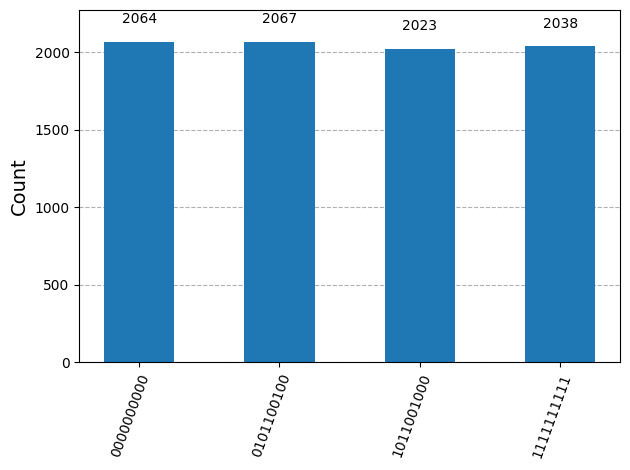

In [40]:
aer_sim = AerSimulator()

try:
    t_qc_image = transpile(qc_image, backend=aer_sim, optimization_level=1)
    job_neqr = aer_sim.run(t_qc_image, shots=8192)
except Exception as e:
    print("[warn] transpile failed, running without transpile:", repr(e))
    job_neqr = aer_sim.run(qc_image, shots=8192)

result_neqr = job_neqr.result()

# circuitが1本の場合
# 複数の場合は get_counts(0) で index 指定する
counts_neqr = result_neqr.get_counts()

print('Encoded: 00 = 0')
print('Encoded: 01 = 01100100')
print('Encoded: 10 = 11001000')
print('Encoded: 11 = 1')

print(counts_neqr)
plot_histogram(counts_neqr)